In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor

In [3]:
df=pd.read_csv("/content/calories.csv")

In [4]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [6]:
df.shape

(15000, 9)

In [7]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


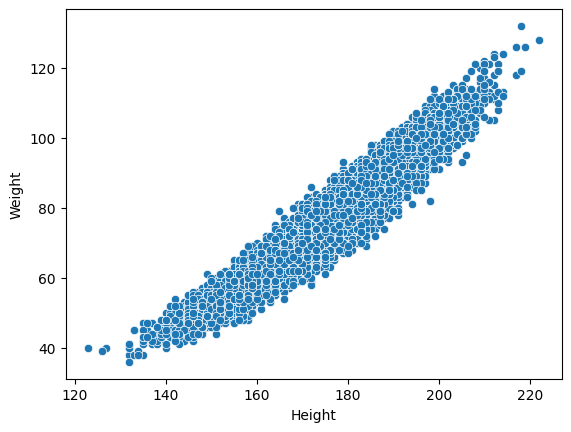

/tmp/ipykernel_2658/1970141152.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"male":0,"female":1})


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3,11.0


In [8]:
sb.scatterplot(x="Height",y="Weight",data=df)
plt.show()
df.replace({"male":0,"female":1})

In [9]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


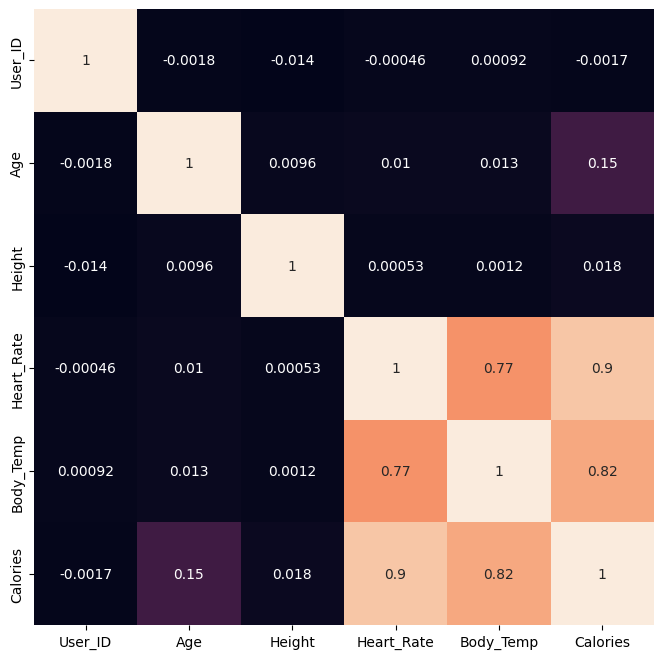

KeyError: "['Weight', 'Duration'] not found in axis"

In [17]:
plt.figure(figsize=(8, 8))

numeric_df = df.select_dtypes(include=['number'])   # ✅ key fix

sb.heatmap(numeric_df.corr(), annot=True, cbar=False)

plt.show()

to_remove = ["Weight", "Duration"]
df.drop(to_remove, axis=1, inplace=True)

features = df.drop(["User_ID", "Calories"], axis=1)
target = df["Calories"].values

X_train, X_val, Y_train, Y_val = train_test_split(
    features, target,
    test_size=0.1,
    random_state=22
)

X_train.shape, X_val.shape

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

from sklearn.metrics import mean_absolute_error as mae
models = RandomForestRegressor()

models.fit(X_train, Y_train)
train_preds = models.predict(X_train)
print("Training Error:", mae(Y_train, train_preds))

val_preds = models.predict(X_val)
print("Validation Error:", mae(Y_val, val_preds))

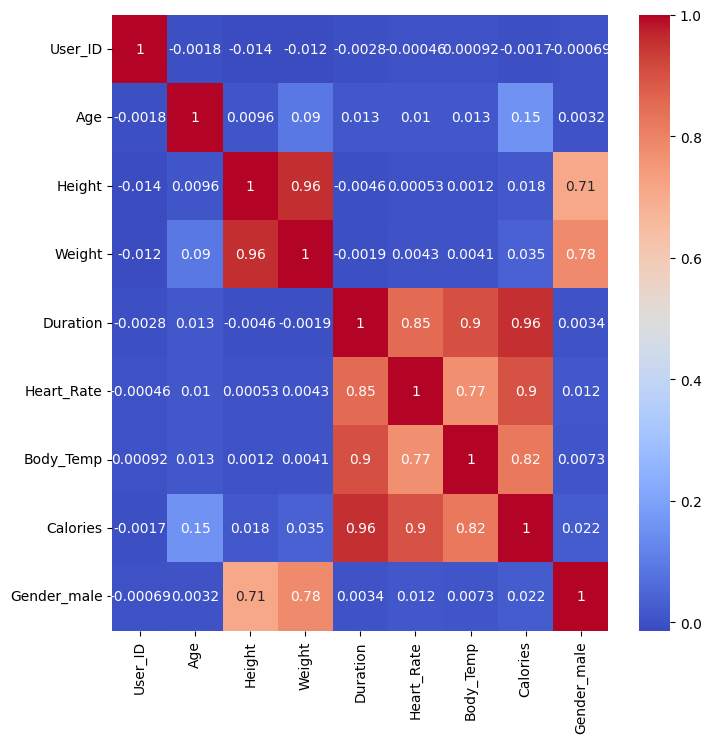

Mean Absolute Error: 8.410690094668839


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

df = pd.read_csv("calories.csv")



df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(8, 8))
sb.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


features = df.drop(["User_ID", "Calories"], axis=1)
target = df["Calories"]


X_train, X_val, Y_train, Y_val = train_test_split(
    features, target,
    test_size=0.1,
    random_state=22
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


model = LinearRegression()
model.fit(X_train, Y_train)

preds = model.predict(X_val)

error = mean_absolute_error(Y_val, preds)
print("Mean Absolute Error:", error)